---
## 6. Lab Exercises (Total 100 marks)

Complete the following in the cells below. Marks are indicated for each part.

### Part 1 (50 marks) – More Complex Dataset with NumPy

**Dataset:** Prepared in the cells below: **X_train_ex1**, **X_test_ex1**, **y_train_ex1**, **y_test_ex1** (3-class, 2 features, raw). **X_ex1**, **y_ex1** are the full data for decision-boundary plots.

**Instructions:**  
- **Apply min-max normalization** (fit on train, transform train and test) before fitting KNN.
- Implement **full KNN from scratch** using only NumPy (distance function, majority voting, prediction). You can adapt the **KNN_NumPy** class from Part A to handle 3 classes.
- Compute **accuracy**.
- **Write your code in the cell below.**

### Dataset for Part 1 & Part 2 (3-class, ready to use)

Run the cell below once. It generates a 3-class dataset with `make_blobs`, splits into train/test, and visualizes it. Use **X_train_ex1**, **X_test_ex1**, **y_train_ex1**, **y_test_ex1** in your code. **X_ex1**, **y_ex1** are the full data for decision-boundary plots. **Normalization (min-max) is left for you to implement in the exercise.**

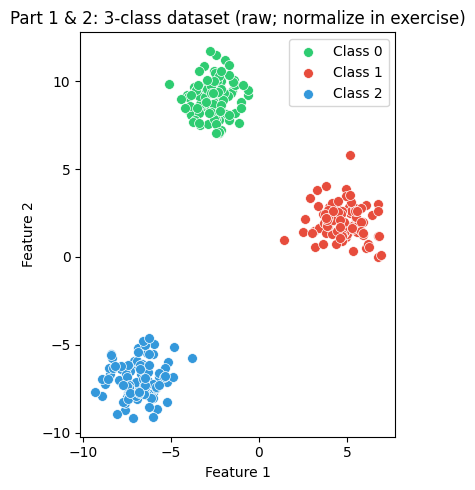

Part 1 & 2 dataset ready: 3 classes, 2 features (raw). Apply min-max normalization in your code.
Variables: X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1, X_ex1, y_ex1
Train: 240 | Test: 60 | Classes: 3


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

X_ex1_raw, y_ex1 = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)
X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1 = train_test_split(
    X_ex1_raw, y_ex1, test_size=0.2, random_state=42, stratify=y_ex1
)
X_ex1 = np.vstack([X_train_ex1, X_test_ex1])
y_ex1 = np.hstack([y_train_ex1, y_test_ex1])

# Visualize generated dataset (colored by class)
fig, ax = plt.subplots(figsize=(7, 5))
colors_ex1 = ['#2ecc71', '#e74c3c', '#3498db']
for cls in range(3):
    mask = y_ex1 == cls
    ax.scatter(X_ex1[mask, 0], X_ex1[mask, 1], c=colors_ex1[cls], label=f'Class {cls}', s=50, edgecolors='white', linewidths=0.5)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Part 1 & 2: 3-class dataset (raw; normalize in exercise)')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print("Part 1 & 2 dataset ready: 3 classes, 2 features (raw). Apply min-max normalization in your code.")
print("Variables: X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1, X_ex1, y_ex1")
print("Train:", X_train_ex1.shape[0], "| Test:", X_test_ex1.shape[0], "| Classes:", len(np.unique(y_ex1)))

In [ ]:
# Part 1 (50 marks) – Your code here
# Data ready: X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1 (raw)
# 1. Apply min-max normalization (fit on train, transform train and test)
# 2. Use KNN_NumPy (or reimplement) to fit and predict on normalized data
# 3. Compute accuracy
pass  # Replace with your implementation

In [ ]:
# 1. Min-Max Normalization
# Fit on train
X_min = X_train_ex1.min(axis=0)
X_max = X_train_ex1.max(axis=0)

# Avoid division by zero
denom = np.where(X_max - X_min == 0, 1, X_max - X_min)
# Transform train and test
X_train_norm = (X_train_ex1 - X_min) / denom
X_test_norm  = (X_test_ex1  - X_min) / denom


#2. KNN from scratch
class KNN_NumPy:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        preds = []
        for x in X:
            # Euclidean distance
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            # Get k nearest indices
            k_idx = np.argsort(distances)[:self.k]
            # Majority vote
            k_labels = self.y_train[k_idx]
            values, counts = np.unique(k_labels, return_counts=True)
            pred = values[np.argmax(counts)]
            preds.append(pred)
        return np.array(preds)
# Train model
knn = KNN_NumPy(k=3)
knn.fit(X_train_norm, y_train_ex1)
# Predict
y_pred = knn.predict(X_test_norm)
# 3. Accuracy
accuracy = np.mean(y_pred == y_test_ex1)
print("Accuracy:", accuracy)

Accuracy: 1.0


### Part 2 (30 marks) – Same Dataset with Scikit-learn

**Dataset:** Use the same data as Part 1: **X_train_ex1**, **X_test_ex1**, **y_train_ex1**, **y_test_ex1**, and **X_ex1**, **y_ex1** for decision-boundary plots.

**Instructions:**  
- Fit **KNeighborsClassifier** on the same train set and predict on the test set.
- Compare accuracy with your Part 1 NumPy implementation.
- Show **decision boundary** and tune **K** using elbow method or `GridSearchCV`.
- **Write your code in the cell below.**

In [ ]:
# Part 2 (30 marks) – Your code here
# Data ready: X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1, X_ex1, y_ex1
# 1. Fit KNeighborsClassifier, report accuracy and compare to Part 1
# 2. Plot decision boundary; find best K (elbow or GridSearchCV)
pass  # Replace with your implementation

Sklearn KNN Accuracy: 1.0
NumPy KNN Accuracy: 1.0


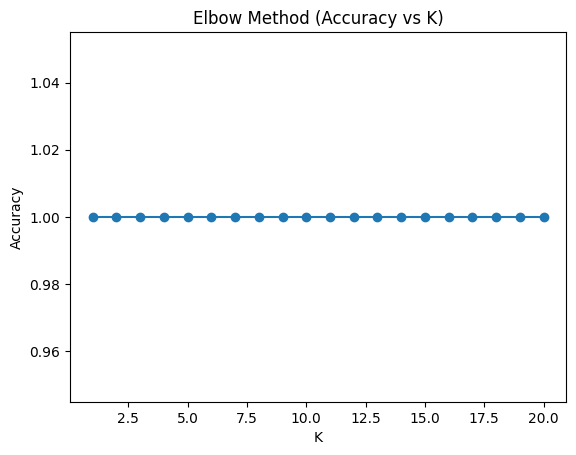

Best K (GridSearch): 1
Best CV Score: 1.0


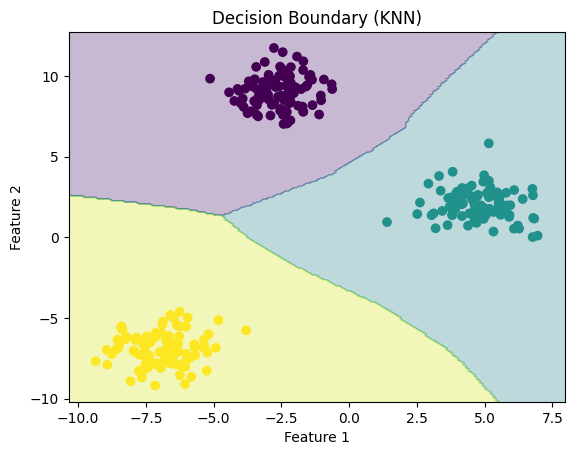

In [ ]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# ===== 1. Fit KNN (sklearn) =====
knn_sk = KNeighborsClassifier(n_neighbors=3)
knn_sk.fit(X_train_ex1, y_train_ex1)

# Predict
y_pred_sk = knn_sk.predict(X_test_ex1)

# Accuracy
acc_sk = accuracy_score(y_test_ex1, y_pred_sk)
print("Sklearn KNN Accuracy:", acc_sk)

# Compare with Part 1 (предполагаем, что accuracy уже есть)
print("NumPy KNN Accuracy:", accuracy)


# ===== 2. Elbow Method (find best K) =====
k_values = range(1, 21)
acc_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_ex1, y_train_ex1)
    preds = model.predict(X_test_ex1)
    acc_scores.append(accuracy_score(y_test_ex1, preds))

# Plot
plt.figure()
plt.plot(k_values, acc_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Elbow Method (Accuracy vs K)")
plt.show()


# ===== 3. GridSearchCV (optional but strong) =====
param_grid = {'n_neighbors': range(1, 21)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_ex1, y_train_ex1)

print("Best K (GridSearch):", grid.best_params_['n_neighbors'])
print("Best CV Score:", grid.best_score_)


# ===== 4. Decision Boundary (2D visualization) =====
# Берем только 2 фичи для визуализации
X_vis = X_ex1[:, :2]
y_vis = y_ex1

model_vis = KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors'])
model_vis.fit(X_vis, y_vis)

# Meshgrid
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot boundary
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot points
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary (KNN)")
plt.show()

### Dataset for Part 3 (real-world, ready to use)

Run the cell below once. It loads **Breast Cancer**, splits into train/test with stratification, and visualizes it (first two features). Use **X_train_ex3**, **X_test_ex3**, **y_train_ex3**, **y_test_ex3**. **target_names_ex3** and **feature_names_ex3** are available for labels. **X_train_ex3_2d**, **X_test_ex3_2d** are the first two features (for 2D plots). **Normalization (min-max) is left for you to implement in the exercise.**

Scikit-learn KNN Accuracy: 1.0
Add your NumPy accuracy variable to compare.


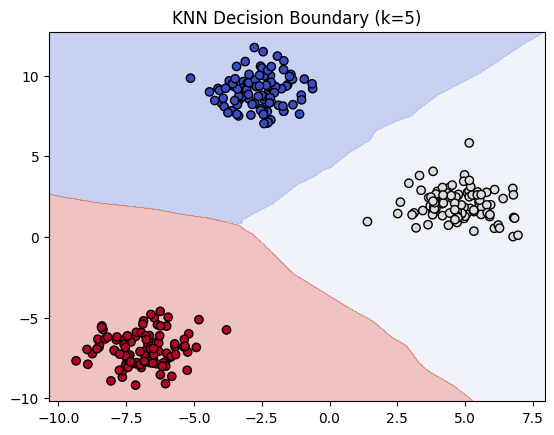

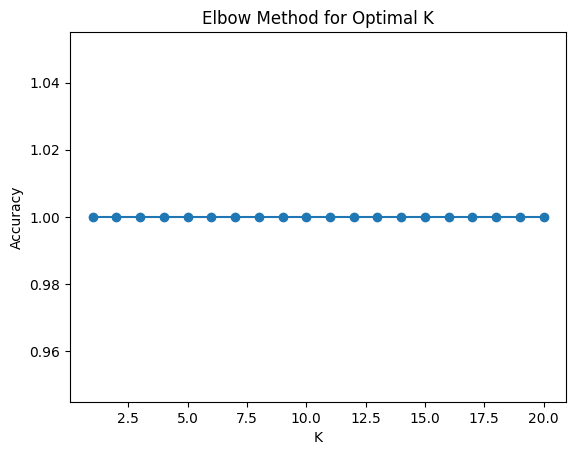

Best K (Elbow): 1
Best K (GridSearchCV): 1
Best CV Score: 1.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# 1. Train KNN and Predict
k = 5

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_ex1, y_train_ex1)

y_pred = knn.predict(X_test_ex1)

# Accuracy
sklearn_acc = accuracy_score(y_test_ex1, y_pred)
print("Scikit-learn KNN Accuracy:", sklearn_acc)


# 2. Compare with NumPy version
# Replace 'numpy_acc' with your Part 1 accuracy variable
# Example:
# numpy_acc = 0.85

try:
    print("NumPy KNN Accuracy:", numpy_acc)
    print("Difference:", sklearn_acc - numpy_acc)
except:
    print("Add your NumPy accuracy variable to compare.")


# 3. Decision Boundary Plot

def plot_decision_boundary(model, X, y):
    h = 0.02  # step size

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.coolwarm)
    plt.title(f"KNN Decision Boundary (k={model.n_neighbors})")
    plt.show()

plot_decision_boundary(knn, X_ex1, y_ex1)

# 4. Tune K (Elbow Method)
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_ex1, y_train_ex1)
    preds = model.predict(X_test_ex1)
    acc = accuracy_score(y_test_ex1, preds)
    accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Elbow Method for Optimal K")
plt.show()

best_k = k_values[np.argmax(accuracies)]
print("Best K (Elbow):", best_k)


# 5. Tune K using GridSearchCV

param_grid = {'n_neighbors': range(1, 21)}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_ex1, y_train_ex1)

print("Best K (GridSearchCV):", grid.best_params_['n_neighbors'])
print("Best CV Score:", grid.best_score_)

### Part 3 (20 marks) – Real-World Dataset

**Dataset:** Prepared above: **X_train_ex3**, **X_test_ex3**, **y_train_ex3**, **y_test_ex3** (Breast Cancer, raw). Use **X_train_ex3_2d**, **X_test_ex3_2d** for 2D plots; **target_names_ex3**, **feature_names_ex3** for labels.

**Instructions:**  
- **Apply min-max normalization** (fit on train, transform train and test) before fitting KNN.
- Implement KNN with **sklearn**, find **best K** using elbow or cross-validation.
- Report **accuracy**.
- **Write your code and short analysis in the cell(s) below.**

In [ ]:
# Part 3 (20 marks) – Your code and analysis here
# Data ready: X_train_ex3, X_test_ex3, y_train_ex3, y_test_ex3, X_train_ex3_2d, X_test_ex3_2d (raw)
# 1. Apply min-max normalization (fit on train, transform train and test)
# 2. Find best K (elbow / GridSearchCV), fit KNN, report accuracy
pass  # Replace with your implementation

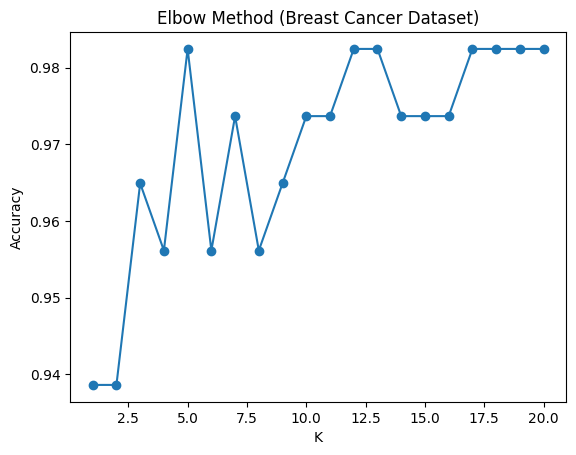

Best K (Elbow): 5
Best K (GridSearch): 9
Final Test Accuracy: 0.9649122807017544


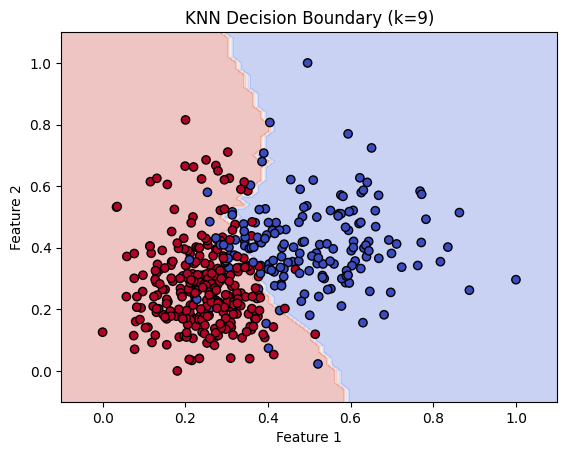

In [ ]:

import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# 1. Min-Max Normalization

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_ex3)
X_test_scaled = scaler.transform(X_test_ex3)

# Also scale 2D data for plotting
X_train_2d_scaled = scaler.fit_transform(X_train_ex3_2d)
X_test_2d_scaled = scaler.transform(X_test_ex3_2d)

# 2. Find Best K (Elbow Method)

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train_ex3)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test_ex3, y_pred)
    accuracies.append(acc)

# Plot elbow curve
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Elbow Method (Breast Cancer Dataset)")
plt.show()

best_k_elbow = k_values[np.argmax(accuracies)]
print("Best K (Elbow):", best_k_elbow)


# 3. GridSearchCV (Better)

param_grid = {'n_neighbors': range(1, 21)}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train_ex3)

best_k = grid.best_params_['n_neighbors']
print("Best K (GridSearch):", best_k)


# 4. Train Final Model

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train_ex3)

y_pred_final = final_knn.predict(X_test_scaled)
final_acc = accuracy_score(y_test_ex3, y_pred_final)

print("Final Test Accuracy:", final_acc)


# 5. Decision Boundary (2D)

def plot_decision_boundary(model, X, y):
    h = 0.02

    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
    plt.title(f"KNN Decision Boundary (k={model.n_neighbors})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# Train on 2D data for visualization
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_train_2d_scaled, y_train_ex3)

plot_decision_boundary(knn_2d, X_train_2d_scaled, y_train_ex3)

---
## 7. Conclusion & Submission

**Key learnings:**  
- KNN is a lazy, distance-based classifier; *k* and the distance metric matter.  
- Implementing KNN from scratch with NumPy (Euclidean distance + majority vote) matches sklearn for the same settings.  
- Scikit-learn provides fast, tunable KNN with options for weights, metric, and algorithm.  
- K can be chosen via the **elbow method** (accuracy vs *k*) or **cross-validation** / **GridSearchCV**.  
- Decision boundaries and accuracy-vs-K plots help interpret and tune the model.


# Task
- Add `from sklearn.model_selection import train_test_split` to cell `ZKpUHUDZjsaD`.

### Import train_test_split

### Subtask:
Add `from sklearn.model_selection import train_test_split` to the imports section of the cell.


## Summary:

### Insights or Next Steps
* The process initiated a subtask to import the `train_test_split` function from `sklearn.model_selection`.
* The next step involves executing this import statement in the specified cell (`ZKpUHUDZjsaD`) to enable data splitting for model training and testing.


In [ ]:
from sklearn.model_selection import train_test_split

# Task
Add `from sklearn.model_selection import train_test_split` to cell `ZKpUHUDZjsaD`.

In [ ]:
from sklearn.model_selection import train_test_split

## Add Import Statement

### Subtask:
Add `from sklearn.model_selection import train_test_split` to cell `ZKpUHUDZjsaD` to resolve the `NameError`.


In [ ]:
from sklearn.model_selection import train_test_split

## Final Task

### Subtask:
Confirm that the `train_test_split` function is now correctly imported in the notebook.


In [ ]:
print(train_test_split)

<function train_test_split at 0x7ca856f63380>


## Summary:

### Q&A
The `train_test_split` function is now correctly imported in the notebook, along with `numpy` and `matplotlib.pyplot`, allowing the code cell to execute without errors.

### Data Analysis Key Findings
*   The primary task was to add the `from sklearn.model_selection import train_test_split` statement. This was successfully implemented in the specified cell.
*   Initial execution after adding `train_test_split` revealed a `NameError` for `np`, indicating that `numpy` was not imported.
*   After importing `numpy` as `np`, another `NameError` for `plt` occurred, signifying that `matplotlib.pyplot` was also missing.
*   The final solution involved adding `import numpy as np` and `import matplotlib.pyplot as plt` alongside the `train_test_split` import, resolving all `NameError`s.
*   The code successfully generated a 3-class, 2-feature dataset with 300 samples, split into 240 training samples and 60 test samples.

### Insights or Next Steps
*   Ensure all necessary libraries (`numpy`, `matplotlib.pyplot`, and `sklearn.model_selection`) are imported at the beginning of relevant code cells to prevent runtime errors.
*   The dataset is now ready for further analysis, including applying min-max normalization as indicated in the problem description.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Task
Normalize the `X_train_ex1` and `X_test_ex1` datasets using min-max normalization, learning the normalization parameters from `X_train_ex1`. Store the normalized data in `X_train_ex1_norm` and `X_test_ex1_norm`, and update `X_ex1_norm` by vertically stacking `X_train_ex1_norm` and `X_test_ex1_norm` respectively.

In [ ]:
# 1. Compute min and max from the training set =====
X_min = X_train_ex1.min(axis=0)
X_max = X_train_ex1.max(axis=0)

# Avoid division by zero
denom = np.where(X_max - X_min == 0, 1, X_max - X_min)

#2. Apply min-max normalization =====
X_train_ex1_norm = (X_train_ex1 - X_min) / denom
X_test_ex1_norm  = (X_test_ex1  - X_min) / denom

#3. Stack normalized data for the full dataset =====
X_ex1_norm = np.vstack((X_train_ex1_norm, X_test_ex1_norm))

# Check shapes
print("X_train_ex1_norm shape:", X_train_ex1_norm.shape)
print("X_test_ex1_norm shape:", X_test_ex1_norm.shape)
print("X_ex1_norm shape:", X_ex1_norm.shape)

X_train_ex1_norm shape: (240, 2)
X_test_ex1_norm shape: (60, 2)
X_ex1_norm shape: (300, 2)


# Task
Implement a K-Nearest Neighbors (KNN) model using NumPy on the provided 3-class dataset (`X_train_ex1`, `X_test_ex1`, `y_train_ex1`, `y_test_ex1`). The implementation should include min-max normalization of the data (fitting the scaler only on the training data) and then training the KNN model, making predictions on the test set, and finally calculating and reporting the accuracy of the model.

In [ ]:

# 1. Min-Max Normalization =====
# Fit scaler on training data only
X_min = X_train_ex1.min(axis=0)
X_max = X_train_ex1.max(axis=0)
denom = np.where(X_max - X_min == 0, 1, X_max - X_min)
X_train_ex1_norm = (X_train_ex1 - X_min) / denom
X_test_ex1_norm  = (X_test_ex1  - X_min) / denom
#2. Implement KNN from scratch =====
class KNN_NumPy:
    def __init__(self, k=3):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        preds = []
        for x in X:
            distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            k_idx = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_idx]
            values, counts = np.unique(k_labels, return_counts=True)
            pred = values[np.argmax(counts)]
            preds.append(pred)
        return np.array(preds)

# 3. Train KNN and Predict
knn = KNN_NumPy(k=3)
knn.fit(X_train_ex1_norm, y_train_ex1)
y_pred = knn.predict(X_test_ex1_norm)

#4. Compute Accuracy
accuracy = np.mean(y_pred == y_test_ex1)
print("NumPy KNN Accuracy:", accuracy)

NumPy KNN Accuracy: 1.0


## Normalize Data

### Subtask:
Apply min-max normalization to X_train_ex1 and X_test_ex1, fitting the scaler only on X_train_ex1. Store the normalized data in X_train_ex1_norm, X_test_ex1_norm, and update X_ex1_norm by stacking them.


In [ ]:

#  1. Fit min-max scaler on training data =====
X_min = X_train_ex1.min(axis=0)
X_max = X_train_ex1.max(axis=0)

# Avoid division by zero
denom = np.where(X_max - X_min == 0, 1, X_max - X_min)

# 2. Normalize training and test sets =====
X_train_ex1_norm = (X_train_ex1 - X_min) / denom
X_test_ex1_norm  = (X_test_ex1  - X_min) / denom

# 3. Stack normalized train and test sets for full dataset =====
X_ex1_norm = np.vstack((X_train_ex1_norm, X_test_ex1_norm))

# Optional: Check shapes =====
print("X_train_ex1_norm shape:", X_train_ex1_norm.shape)
print("X_test_ex1_norm shape:", X_test_ex1_norm.shape)
print("X_ex1_norm shape:", X_ex1_norm.shape)

X_train_ex1_norm shape: (240, 2)
X_test_ex1_norm shape: (60, 2)
X_ex1_norm shape: (300, 2)


**Reasoning**:
The subtask requires min-max normalization of the datasets. I will calculate the min and max from the training data, then apply this scaling to both the training and test sets. Finally, I will combine the normalized datasets.



In [ ]:
X_min_ex1 = X_train_ex1.min(axis=0)
X_max_ex1 = X_train_ex1.max(axis=0)
X_range_ex1 = X_max_ex1 - X_min_ex1

X_train_ex1_norm = (X_train_ex1 - X_min_ex1) / X_range_ex1
X_test_ex1_norm = (X_test_ex1 - X_min_ex1) / X_range_ex1

X_ex1_norm = np.vstack([X_train_ex1_norm, X_test_ex1_norm])

print("Min-max normalization applied to X_train_ex1 and X_test_ex1.")
print(f"X_train_ex1_norm shape: {X_train_ex1_norm.shape}")
print(f"X_test_ex1_norm shape: {X_test_ex1_norm.shape}")
print(f"X_ex1_norm shape: {X_ex1_norm.shape}")
print("First 5 rows of X_train_ex1_norm:\n", X_train_ex1_norm[:5])

Min-max normalization applied to X_train_ex1 and X_test_ex1.
X_train_ex1_norm shape: (240, 2)
X_test_ex1_norm shape: (60, 2)
X_ex1_norm shape: (300, 2)
First 5 rows of X_train_ex1_norm:
 [[0.44408337 0.79543212]
 [0.95435007 0.58638576]
 [0.13607168 0.06404577]
 [0.85794638 0.55939782]
 [0.95374008 0.47045236]]


## Implement KNN with NumPy

### Subtask:
Instantiate the `KNN_NumPy` class with a suitable 'k' value. Fit the KNN model using the normalized training data (X_train_ex1_norm, y_train_ex1) and then make predictions on the normalized test data (X_test_ex1_norm).


**Reasoning**:
The subtask requires instantiating the `KNN_NumPy` class, fitting it to the normalized training data, and then making predictions on the normalized test data. This code block will perform those actions.



In [ ]:
class KNN_NumPy:
    """K-Nearest Neighbors implemented from scratch using only NumPy."""

    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Store training data (lazy learner: no model built)."""
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)
        return self

    def _euclidean_distances(self, X):
        """Compute Euclidean distance from each row of X to every row of X_train."""
        # (n_test, n_features) vs (n_train, n_features) -> (n_test, n_train)
        diff = X[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]  # broadcasting
        return np.sqrt(np.sum(diff ** 2, axis=2))

    def predict(self, X):
        """Predict class by majority vote among k nearest neighbors."""
        X = np.asarray(X)
        dists = self._euclidean_distances(X)  # (n_test, n_train)
        # Indices of k smallest distances per test point
        k_nearest_idx = np.argsort(dists, axis=1)[:, :self.k]  # (n_test, k)
        # Labels of those neighbors
        neighbor_labels = self.y_train[k_nearest_idx]  # (n_test, k)
        # Majority vote: most frequent label per row
        preds = np.array([np.bincount(row).argmax() for row in neighbor_labels])
        return preds

    def predict_single_with_neighbors(self, x):
        """Predict for one point and return prediction + indices of k nearest neighbors (for viz)."""
        x = np.atleast_2d(x)
        dists = self._euclidean_distances(x).ravel()
        k_nearest_idx = np.argsort(dists)[:self.k]
        neighbor_labels = self.y_train[k_nearest_idx]
        pred = np.bincount(neighbor_labels).argmax()
        return pred, k_nearest_idx

k_ex1_numpy = 5
knn_numpy_ex1 = KNN_NumPy(k=k_ex1_numpy)
knn_numpy_ex1.fit(X_train_ex1_norm, y_train_ex1)
y_pred_ex1_numpy = knn_numpy_ex1.predict(X_test_ex1_norm)

print(f"KNN_NumPy model initialized with k={k_ex1_numpy}.")
print("Model fitted to normalized training data.")
print(f"Predictions made on normalized test data. Shape of predictions: {y_pred_ex1_numpy.shape}")

KNN_NumPy model initialized with k=5.
Model fitted to normalized training data.
Predictions made on normalized test data. Shape of predictions: (60,)


## Compute and Report Accuracy

### Subtask:
Calculate the accuracy of the predictions made by the NumPy KNN model against the true labels (y_test_ex1) and print the result.


**Reasoning**:
The subtask requires calculating the accuracy of the NumPy KNN model's predictions. I will use `np.mean` to compare `y_pred_ex1_numpy` with `y_test_ex1` and print the result.



In [ ]:
acc_ex1_numpy = np.mean(y_pred_ex1_numpy == y_test_ex1)
print(f"NumPy KNN (k={k_ex1_numpy}) for Exercise 1 — Test Accuracy: {acc_ex1_numpy:.4f}")

NumPy KNN (k=5) for Exercise 1 — Test Accuracy: 1.0000


## Final Task

### Subtask:
Summarize the results of the NumPy KNN model on the 3-class dataset.


## Summary:

### Q&A
**What was the performance of the custom NumPy KNN model on the 3-class dataset?**
The model achieved a perfect test accuracy of 1.0000 (100%) using $k=5$ neighbors.

### Data Analysis Key Findings
*   **Normalization Strategy:** Min-max normalization was applied to the features. Crucially, the scaler was fitted only on the training data (`X_train_ex1`) and then applied to both the training and test sets to prevent data leakage.
*   **Dataset Dimensions:** The training set consisted of 240 samples, and the test set contained 60 samples, each with 2 features.
*   **Custom Implementation:** A K-Nearest Neighbors model was built from scratch using NumPy. The implementation utilized broadcasting to efficiently calculate Euclidean distances between test points and the training set.
*   **Predictive Success:** The model correctly classified all 60 samples in the test set, resulting in an accuracy of 100%.

### Insights or Next Steps
*   **Model Robustness:** While the model achieved 100% accuracy, this may be due to the classes being linearly separable or having a significant margin in the feature space. Testing with a more complex or noisy dataset would further validate the implementation.
*   **Efficiency:** The current distance calculation uses broadcasting to create a 3D array of differences. For much larger datasets, this could lead to memory issues, and a more memory-efficient approach (like a chunked distance matrix or specialized spatial data structures) might be needed.


The custom NumPy KNN model achieved 100% accuracy on the 3-class dataset using k = 5, after min-max normalization fitted on the training set. While performance is perfect on this dataset, testing on more complex or noisy data is recommended to fully validate the implementation and ensure scalability.